In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob

os.makedirs("figures", exist_ok=True)

# Find the processed CSV
csv_files = glob.glob("../data/processed/trajectories_*.csv")
if not csv_files:
    raise FileNotFoundError("No processed trajectory CSV found. Run download_data.py first.")
csv_path = csv_files[0]
print(f"Loading {csv_path}...")
df = pd.read_csv(csv_path)
df.head()

Loading ../data/processed/trajectories_synthetic.csv...


,vehicle_id,mode,time_s,x_m,y_m,speed_mps
0,52,car,8.28,0.00,4.64,7.61
1,52,car,9.28,7.61,4.64,7.61
2,52,car,10.28,15.22,4.64,7.61
3,52,car,11.28,22.83,4.64,7.61
4,52,car,12.28,30.44,4.64,7.61


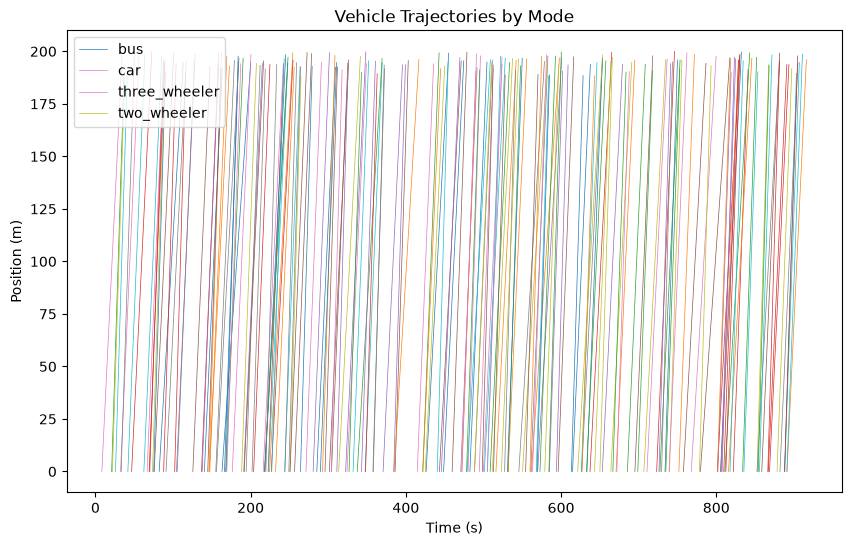

In [2]:
# Plot (a) Trajectories (x vs t)
fig, ax = plt.subplots(figsize=(10, 6))
for mode, group in df.groupby("mode"):
    for vid, vgroup in group.groupby("vehicle_id"):
        ax.plot(vgroup["time_s"], vgroup["x_m"], label=mode if vid == group["vehicle_id"].iloc[0] else "", linewidth=0.5)

ax.set_xlabel("Time (s)")
ax.set_ylabel("Position (m)")
ax.set_title("Vehicle Trajectories by Mode")
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())
plt.savefig("figures/trajectories.png")
plt.show()

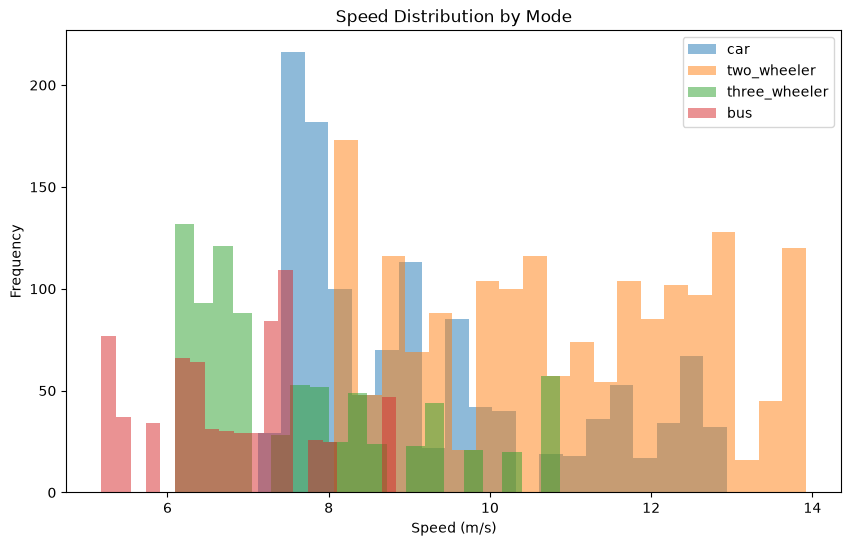

In [3]:
# Plot (b) Histogram of speeds per mode
fig, ax = plt.subplots(figsize=(10, 6))
for mode in df["mode"].unique():
    speeds = df[df["mode"] == mode]["speed_mps"]
    ax.hist(speeds, bins=20, alpha=0.5, label=mode)

ax.set_xlabel("Speed (m/s)")
ax.set_ylabel("Frequency")
ax.set_title("Speed Distribution by Mode")
ax.legend()
plt.savefig("figures/speeds.png")
plt.show()

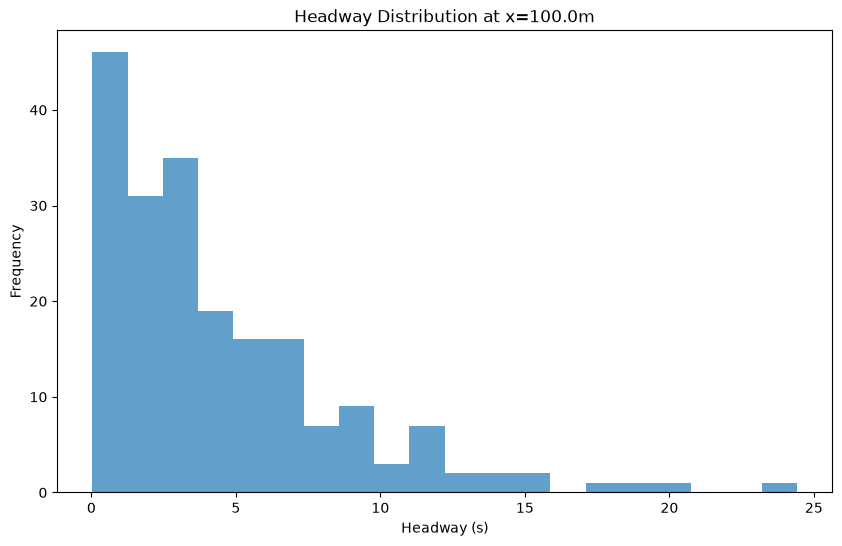

In [4]:
# Plot (c) Headway distribution at a specific cross-section (x = 100m)
cross_section_x = 100.0
crossing_times = []
for vid, group in df.groupby("vehicle_id"):
    # Interpolate time when vehicle crosses x = 100
    if group["x_m"].min() <= cross_section_x <= group["x_m"].max():
        t_cross = np.interp(cross_section_x, group["x_m"], group["time_s"])
        crossing_times.append(t_cross)

crossing_times.sort()
headways = np.diff(crossing_times)

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(headways, bins=20, alpha=0.7)
ax.set_xlabel("Headway (s)")
ax.set_ylabel("Frequency")
ax.set_title(f"Headway Distribution at x={cross_section_x}m")
plt.savefig("figures/headways.png")
plt.show()